---
title: 'Expected Performance of a Mean-Reversion Trading Strategy — Part 4'
date: 2026-03-03
description: "How does parameter estimation error affect the Sharpe ratio of a mean-reversion strategy?"
categories: [Quantitative Finance, Trading Strategies, Stochastic Processes]
---

In [Part 1](../mean-reversion-strategy-1/index.qmd) we derived the asymptotic Sharpe ratio $\mathrm{SR}_\infty = \sqrt{\theta/2}$ of a mean-reversion strategy under the assumption that the mispricing follows an Ornstein-Ulenbeck process and the trader knows its parameters exactly. [Part 2](../mean-reversion-strategy-2/draft.ipynb) showed that a constant bias $M$ in the fair-value estimate incurs a multiplicative penalty $(1 + 2\theta M^2/\sigma^2)^{-1/2}$, and [Part 3](../mean-reversion-strategy-3/draft.ipynb) extended this to correlated bias, establishing that any trailing estimator of the faie value using past log prices degrades both expected PnL and risk.

All three parts treated the OU parameters $\theta$ and $\sigma$ as known. In practice, these must be estimated from a finite calibration sample, and estimation error feeds directly into the trader's fair-value estimate. In this post we close the loop by quantifying how parameter estimation error affects the realised Sharpe ratio.

We look at the effect of the two estimates separately. The first is the mean estimation error ($\hat\mu \neq \mu$): the estimated long-run mean acts as a constant bias in the Part 2 sense, with variance $\mathrm{Var}(\hat\mu) \approx \sigma^2/(\theta^2 T_{\mathrm{est}})$, yielding a penalty $(1 + 2/(\theta T_{\mathrm{est}}))^{-1/2}$ governed entirely by the number of mean-reversion timescales in the calibration window. The second is speed estimation error ($\hat\theta \neq \theta$): the well-known [finite-sample bias in $\hat\theta$](../short-rate-models-4/index.qmd) does not degrade realised SR — which is scale-invariant in position size — yet creates systematic overconfidence, as the trader predicts a higher SR than is actually achieved, leading to misallocated capital and underestimated drawdowns.

A further contribution of this post is to show that rolling re-estimation is equivalent to a Part 3 trailing estimator, thereby unifying the estimation-error penalty derived here with the correlated-bias penalty from the previous instalment.

In [13]:
#| echo: false
#| output: false
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

rng = np.random.default_rng(42)

# --- OU helpers (same conventions as Parts 1–3) ---

def s2(t, theta, sigma):
    """Variance of X_t: sigma^2/(2*theta) * (1 - exp(-2*theta*t))."""
    return sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))


def simulate_ou(theta, sigma, T, dt, n_paths, mu=0.0, rng=rng):
    """Euler–Maruyama: dX = -theta*(X - mu) dt + sigma dW, X_0=mu."""
    n_steps = int(T / dt)
    X = np.full((n_paths, n_steps + 1), mu)
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        X[:, i + 1] = X[:, i] - theta * (X[:, i] - mu) * dt + sigma * dW
    return X


def pnl_paths(X, M, dt):
    """PnL paths: dY = -(X - M) dX.

    M can be: scalar, 1-D array (n_paths,) for per-path constant bias,
    or 2-D array (n_paths, n_steps+1) for time-varying bias.
    """
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    if np.ndim(M) == 2:
        M_mid = M[:, :-1]
    elif np.ndim(M) == 1:
        M_mid = M[:, None]
    else:
        M_mid = M
    dY = -(X_mid - M_mid) * dX
    Y = np.cumsum(dY, axis=1)
    return np.concatenate([np.zeros((X.shape[0], 1)), Y], axis=1)


# --- MLE for the OU process (exact discretisation) ---

def mle_ou(X_path, dt):
    """MLE for a single OU path via AR(1) regression.

    X_{i+1} | X_i ~ N(a*X_i + b, s2_eps)
    where a = exp(-theta*dt), b = mu*(1 - a), s2_eps = sigma^2/(2*theta)*(1-a^2).

    Returns (theta_hat, mu_hat, sigma_hat).
    """
    y = X_path[1:]
    x = X_path[:-1]
    n = len(y)
    # OLS: y = a*x + b + eps
    Sx = np.sum(x)
    Sy = np.sum(y)
    Sxx = np.sum(x * x)
    Sxy = np.sum(x * y)
    denom = n * Sxx - Sx * Sx
    a_hat = (n * Sxy - Sx * Sy) / denom
    b_hat = (Sy - a_hat * Sx) / n
    # Clamp a_hat to avoid log of non-positive or unit root
    a_hat = np.clip(a_hat, 1e-12, 1 - 1e-6)
    theta_hat = -np.log(a_hat) / dt
    # mu_hat = b/(1-a); fall back to sample mean when a ≈ 1
    if abs(1 - a_hat) < 1e-4:
        mu_hat = np.mean(X_path)
    else:
        mu_hat = b_hat / (1 - a_hat)
    # Residual variance
    eps = y - a_hat * x - b_hat
    s2_eps = np.mean(eps**2)
    sigma_hat = np.sqrt(2 * theta_hat * s2_eps / (1 - a_hat**2))
    return theta_hat, mu_hat, sigma_hat


print("Helpers loaded.")

Helpers loaded.


# Maximum Likelihood Estimation for the OU Process

We work with the same centred OU model as Parts 1–3:

$$dX_t = -\theta\,(X_t - \mu)\,dt + \sigma\,dW_t, \qquad X_0 = \mu.$$

For the trading strategy, $X_t$ represents the mispricing — the deviation from fair value $v$, with $\mu = v$ denoting the true long-run mean. The trader must estimate the parameter triple $(\theta, \mu, \sigma)$ from a calibration sample of length $T_{\mathrm{est}}$.

As derived in a [previous post in our short-rate model series](../short-rate-models-4/index.qmd), the exact discretisation of this process is

$$X_{i+1} \mid X_i \;\sim\; \mathcal{N}\!\big(\underbrace{X_i\,e^{-\theta\Delta t} + \mu(1 - e^{-\theta\Delta t})}_{\text{conditional mean}},\;\; \underbrace{\tfrac{\sigma^2}{2\theta}(1 - e^{-2\theta\Delta t})}_{\text{conditional variance}}\big),$$

which takes the form of a Gaussian AR(1) model $X_{i+1} = a X_i + b + \varepsilon_i$ with $a = e^{-\theta\Delta t}$ and $b = \mu(1-a)$. Maximum likelihood estimation therefore reduces to OLS regression, and the OU parameters are recovered by inverting:

$$\hat\theta = -\frac{\log\hat{a}}{\Delta t}, \qquad \hat\mu = \frac{\hat{b}}{1-\hat{a}}, \qquad \hat\sigma^2 = \frac{2\hat\theta\,\hat{s}^2_\varepsilon}{1-\hat{a}^2}.$$

Three finite-sample difficulties plague this estimator. First, when $\theta$ is small, $a \approx 1$ and the process resembles a random walk; since the intercept takes the form $\mu(1-a)$, the estimates $\hat\mu$ and $\hat\theta$ become strongly negatively correlated — a slight change in one can be compensated by the other, creating an identification problem. Second, the MLE $\hat\theta$ is upward-biased in finite samples: small-sample variability causes $\hat{a}$ to be pulled below $e^{-\theta\Delta t}$, which inflates $\hat\theta$. Third, all three estimators exhibit high variance when $\theta T_{\mathrm{est}}$ is small, reflecting the fact that the process has not completed enough mean-reversion cycles to reveal its parameters reliably.

@fig-mle-bias illustrates these effects across calibration windows of 2, 5, 10, and 20 years. The top row shows the distribution of $\hat\theta$: the median exceeds the true value at short windows and converges from above as more data is observed. The bottom row shows $\hat\mu$: the distribution is centred at the true mean in all cases, but its standard deviation shrinks only as $\sigma/(\theta\sqrt{T_{\mathrm{est}}})$, confirming the slow convergence rate inherent to autocorrelated processes.

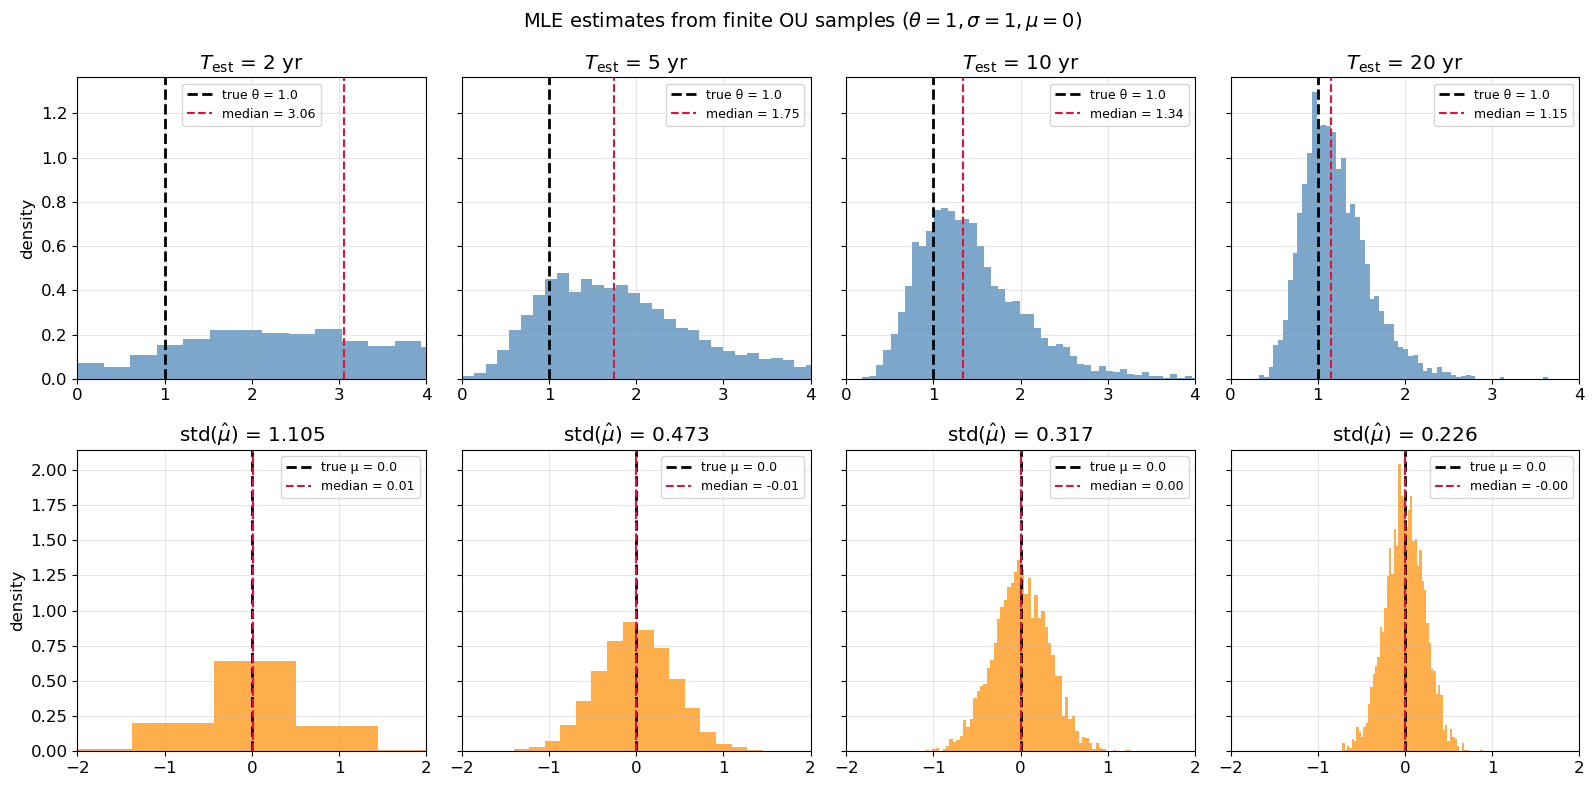

 T_est |  median θ̂ |    mean θ̂ |     std θ̂ |     std μ̂ |  theory std μ̂
----------------------------------------------------------------------
     2 |      3.058 |      3.594 |      2.399 |      1.105 |          0.707
     5 |      1.748 |      1.956 |      1.087 |      0.473 |          0.447
    10 |      1.337 |      1.442 |      0.621 |      0.317 |          0.316
    20 |      1.153 |      1.207 |      0.380 |      0.226 |          0.224


In [14]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-mle-bias
#| fig-cap: "Finite-sample distributions of MLE estimates $\\hat\\theta$ (top) and $\\hat\\mu$ (bottom) for calibration windows of 2, 5, 10, and 20 years ($\\theta=1, \\sigma=1, \\mu=0$). The upward bias in $\\hat\\theta$ and the high variance of $\\hat\\mu$ diminish as the calibration window lengthens."
# --- Finite-sample bias in MLE estimates ---
theta_true, sigma_true, mu_true = 1.0, 1.0, 0.0
dt = 1 / 252
n_mc = 3000
T_est_values = [2, 5, 10, 20]

fig, axes = plt.subplots(2, len(T_est_values), figsize=(16, 8), sharex='row', sharey='row')

for j, T_est in enumerate(T_est_values):
    theta_hats, mu_hats = [], []
    for i in range(n_mc):
        X = simulate_ou(theta_true, sigma_true, T_est, dt, 1,
                        mu=mu_true, rng=np.random.default_rng(1000 * j + i))
        th, mh, sh = mle_ou(X[0], dt)
        theta_hats.append(th)
        mu_hats.append(mh)
    theta_hats = np.array(theta_hats)
    mu_hats = np.array(mu_hats)

    # theta histogram
    ax = axes[0, j]
    ax.hist(theta_hats, bins=60, density=True, alpha=0.7, color='steelblue')
    ax.axvline(theta_true, color='black', ls='--', lw=2, label=f'true θ = {theta_true}')
    ax.axvline(np.median(theta_hats), color='crimson', ls='--', lw=1.5,
               label=f'median = {np.median(theta_hats):.2f}')
    ax.set_title(f'$T_{{\\mathrm{{est}}}}$ = {T_est} yr')
    ax.legend(fontsize=9)
    if j == 0:
        ax.set_ylabel('density')

    # mu histogram
    ax = axes[1, j]
    ax.hist(mu_hats, bins=60, density=True, alpha=0.7, color='darkorange')
    ax.axvline(mu_true, color='black', ls='--', lw=2, label=f'true μ = {mu_true}')
    ax.axvline(np.median(mu_hats), color='crimson', ls='--', lw=1.5,
               label=f'median = {np.median(mu_hats):.2f}')
    std_mu = np.std(mu_hats)
    ax.set_title(f'std($\\hat\\mu$) = {std_mu:.3f}')
    ax.legend(fontsize=9)
    if j == 0:
        ax.set_ylabel('density')

axes[0, 0].set_xlim(0, 4)
axes[1, 0].set_xlim(-2, 2)
fig.suptitle(r'MLE estimates from finite OU samples ($\theta=1, \sigma=1, \mu=0$)', fontsize=14)
fig.tight_layout()
plt.show()

# Print summary table
print(f"{'T_est':>6} | {'median θ̂':>10} | {'mean θ̂':>10} | {'std θ̂':>10} | {'std μ̂':>10} | {'theory std μ̂':>14}")
print("-" * 70)
for j, T_est in enumerate(T_est_values):
    theta_hats, mu_hats = [], []
    for i in range(n_mc):
        X = simulate_ou(theta_true, sigma_true, T_est, dt, 1,
                        mu=mu_true, rng=np.random.default_rng(1000 * j + i))
        th, mh, sh = mle_ou(X[0], dt)
        theta_hats.append(th)
        mu_hats.append(mh)
    theta_hats = np.array(theta_hats)
    mu_hats = np.array(mu_hats)
    theory_std = sigma_true / (theta_true * np.sqrt(T_est))
    print(f"{T_est:>6} | {np.median(theta_hats):>10.3f} | {np.mean(theta_hats):>10.3f} | "
          f"{np.std(theta_hats):>10.3f} | {np.std(mu_hats):>10.3f} | {theory_std:>14.3f}")

# The Estimation Penalty on Sharpe Ratio

## Setup: one-shot estimation then trading

The trader observes the OU process on a calibration window $[0, T_{\mathrm{est}}]$, estimates $(\hat\theta, \hat\mu, \hat\sigma)$ via MLE, then trades on $[T_{\mathrm{est}}, T_{\mathrm{est}} + T_{\mathrm{trade}}]$ using $\hat\mu$ as the fair-value estimate.

From Part 2, the asymptotic Sharpe ratio when the trader operates with a constant bias $M$ is

$$\mathrm{SR}_\infty = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \dfrac{2\theta M^2}{\sigma^2}}}.$$

Part 2 also demonstrated that expected PnL is unaffected by a constant bias — the degradation acts purely through increased variance. During the trading window, the estimation error in $\hat\mu$ behaves exactly as a Part 2 constant bias: it is fixed at the moment calibration ends and is independent of the future Brownian increments on $[T_{\mathrm{est}}, T_{\mathrm{est}} + T_{\mathrm{trade}}]$.

## Variance of $\hat\mu$

For a stationary OU process with mean $\mu$, the sample mean $\bar{X} = \frac{1}{T}\int_0^T X_t\,dt$ satisfies

$$\mathrm{Var}(\bar{X}) = \frac{1}{T^2}\int_0^T\!\int_0^T \mathrm{Cov}(X_s, X_t)\,ds\,dt = \frac{\sigma^2}{\theta^2 T}\left(1 - \frac{1 - e^{-\theta T}}{\theta T}\right).$$

When $\theta T$ is large (many half-lives), $\mathrm{Var}(\bar{X}) \approx \sigma^2/(\theta^2 T)$. The MLE $\hat\mu$ coincides with $\bar{X}$ asymptotically, giving

$$\mathbb{E}[\hat\mu^2] = \mathrm{Var}(\hat\mu) \approx \frac{\sigma^2}{\theta^2 T_{\mathrm{est}}}.$$

## The penalty formula

Substituting $M^2 \to \mathbb{E}[\hat\mu^2]$ into the Part 2 formula — just as we substituted $M^2 \to \sigma_M^2$ for a random independent bias in Part 3 — yields

$$\boxed{\mathrm{SR}_\infty = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \dfrac{2}{\theta\, T_{\mathrm{est}}}}}.}$$

The penalty factor $\left(1 + 2/(\theta T_{\mathrm{est}})\right)^{-1/2}$ depends only on the dimensionless product $\theta T_{\mathrm{est}}$ — the number of mean-reversion timescales observed during calibration. To achieve a penalty smaller than $1/\sqrt{2} \approx 0.71$, we need $\theta T_{\mathrm{est}} > 2$, meaning the trader must observe at least two full mean-reversion timescales. @tbl-estimation-penalty shows the penalty across a range of calibration lengths.

| $\theta T_{\mathrm{est}}$ | Penalty | Half-lives observed |
|:---:|:---:|:---:|
| 1 | 0.577 | 1.4 |
| 2 | 0.707 | 2.9 |
| 5 | 0.845 | 7.2 |
| 10 | 0.913 | 14.4 |
| 20 | 0.953 | 28.9 |

: Estimation penalty as a function of calibration length $\theta T_{\mathrm{est}}$. {#tbl-estimation-penalty}

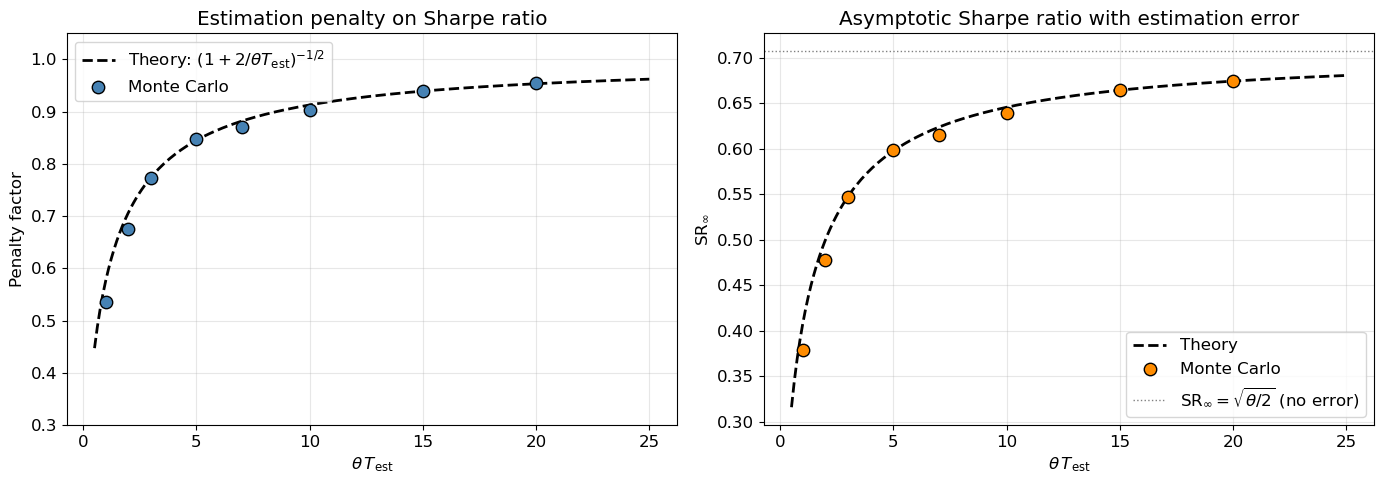

SR_∞ (no error): 0.7071
  T_est= 1yr  θT=  1.0  SR_mc=0.3790  SR_theory=0.4082
  T_est= 2yr  θT=  2.0  SR_mc=0.4774  SR_theory=0.5000
  T_est= 3yr  θT=  3.0  SR_mc=0.5471  SR_theory=0.5477
  T_est= 5yr  θT=  5.0  SR_mc=0.5990  SR_theory=0.5976
  T_est= 7yr  θT=  7.0  SR_mc=0.6151  SR_theory=0.6236
  T_est=10yr  θT= 10.0  SR_mc=0.6393  SR_theory=0.6455
  T_est=15yr  θT= 15.0  SR_mc=0.6649  SR_theory=0.6642
  T_est=20yr  θT= 20.0  SR_mc=0.6748  SR_theory=0.6742


In [15]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-estimation
#| fig-cap: "Estimation penalty on Sharpe ratio vs calibration length $\\theta T_{\\mathrm{est}}$. Left: penalty factor. Right: absolute SR. Monte Carlo dots closely track the theoretical curve $(1 + 2/\\theta T_{\\mathrm{est}})^{-1/2}$."
# --- SR vs estimation window: theory + MC ---
theta_true, sigma_true, mu_true = 1.0, 1.0, 0.0
dt = 1 / 252
T_trade = 100         # long trading window for asymptotic SR
n_mc = 2000           # MC paths for estimation

T_est_grid = np.array([1, 2, 3, 5, 7, 10, 15, 20])
sr_theory = np.sqrt(theta_true / 2) / np.sqrt(1 + 2 / (theta_true * T_est_grid))
sr_mc = []

for T_est in T_est_grid:
    pnl_per_year = []
    qvY_per_year = []
    for i in range(n_mc):
        seed_est = int(10000 * T_est + i)
        X_full = simulate_ou(theta_true, sigma_true, T_est + T_trade, dt, 1,
                             mu=mu_true, rng=np.random.default_rng(seed_est))
        n_est_steps = int(T_est / dt)
        X_cal = X_full[0, :n_est_steps + 1]
        X_trade = X_full[:, n_est_steps:]  # keep 2D

        _, mu_hat, _ = mle_ou(X_cal, dt)

        # PnL and QV of Y (not X)
        Y = pnl_paths(X_trade, mu_hat, dt)
        pnl_per_year.append(Y[0, -1] / T_trade)
        dX_tr = np.diff(X_trade, axis=1)
        dY = -(X_trade[:, :-1] - mu_hat) * dX_tr
        qvY = np.sum(dY**2, axis=1)[0]
        qvY_per_year.append(qvY / T_trade)

    mean_pnl = np.mean(pnl_per_year)
    mean_qvY = np.mean(qvY_per_year)
    sr_mc.append(mean_pnl / np.sqrt(mean_qvY))

sr_mc = np.array(sr_mc)

# --- Plot: SR penalty vs theta * T_est ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

theta_T_fine = np.linspace(0.5, 25, 200)
penalty_theory = 1 / np.sqrt(1 + 2 / theta_T_fine)
axes[0].plot(theta_T_fine, penalty_theory, 'k--', lw=2,
             label='Theory: $(1 + 2/\\theta T_{\\mathrm{est}})^{-1/2}$')
penalty_mc = sr_mc / np.sqrt(theta_true / 2)
axes[0].scatter(theta_true * T_est_grid, penalty_mc, s=80, c='steelblue',
                zorder=5, edgecolors='black', label='Monte Carlo')
axes[0].set_xlabel(r'$\theta \, T_{\mathrm{est}}$')
axes[0].set_ylabel('Penalty factor')
axes[0].set_title('Estimation penalty on Sharpe ratio')
axes[0].legend()
axes[0].set_ylim(0.3, 1.05)

sr_fine = np.sqrt(theta_true / 2) * penalty_theory
axes[1].plot(theta_T_fine, sr_fine, 'k--', lw=2, label=r'Theory')
axes[1].scatter(theta_true * T_est_grid, sr_mc, s=80, c='darkorange',
                zorder=5, edgecolors='black', label='Monte Carlo')
axes[1].axhline(np.sqrt(theta_true / 2), color='gray', ls=':', lw=1,
                label=r'$\mathrm{SR}_\infty = \sqrt{\theta/2}$ (no error)')
axes[1].set_xlabel(r'$\theta \, T_{\mathrm{est}}$')
axes[1].set_ylabel(r'$\mathrm{SR}_\infty$')
axes[1].set_title('Asymptotic Sharpe ratio with estimation error')
axes[1].legend()

fig.tight_layout()
plt.show()

print(f"SR_∞ (no error): {np.sqrt(theta_true/2):.4f}")
for T_est, sr in zip(T_est_grid, sr_mc):
    print(f"  T_est={T_est:>2d}yr  θT={theta_true*T_est:>5.1f}  SR_mc={sr:.4f}  "
          f"SR_theory={np.sqrt(theta_true/2)/np.sqrt(1+2/(theta_true*T_est)):.4f}")

# The Correlation Channel is Transient

In Part 3, a correlated bias was shown to degrade expected PnL via $-\theta\int_0^t \mathrm{Cov}(M_u, X_u)\,du$, not just risk. A natural concern is whether the one-shot estimator $\hat\mu$ — computed from the calibration window — introduces this additional penalty.

Asymptotically, it does not. Note that $X_t$ for $t > T_{\mathrm{est}}$ depends on the calibration window only through $X_{T_{\mathrm{est}}}$. Since $\hat\mu$ is a function of $\{X_s : s \leq T_{\mathrm{est}}\}$, the covariance decays exponentially as the trading window progresses:

$$\mathrm{Cov}(\hat\mu, X_t) \;=\; \mathrm{Cov}\big(\hat\mu, X_{T_{\mathrm{est}}}\big) \cdot e^{-\theta(t - T_{\mathrm{est}})}, \qquad t > T_{\mathrm{est}}.$$

The cumulative PnL degradation from the Part 3 covariance channel is therefore

$$\frac{\theta}{T_{\mathrm{trade}}}\int_{T_{\mathrm{est}}}^{T_{\mathrm{est}}+T_{\mathrm{trade}}} \mathrm{Cov}(\hat\mu, X_t)\,dt \;=\; \mathrm{Cov}(\hat\mu, X_{T_{\mathrm{est}}})\cdot\frac{1 - e^{-\theta T_{\mathrm{trade}}}}{T_{\mathrm{trade}}} \;\to\; 0$$

as $T_{\mathrm{trade}} \to \infty$. The correlation effect is washed out by the long trading horizon.

For one-shot estimation, the entire SR penalty therefore comes from the Part 2 variance channel: $\hat\mu$ acts as a random constant bias with $\mathbb{E}[\hat\mu^2] \approx \sigma^2/(\theta^2 T_{\mathrm{est}})$, yielding the clean formula $(1 + 2/(\theta T_{\mathrm{est}}))^{-1/2}$. @fig-sr-estimation confirms this result with Monte Carlo simulation.

# Rolling Estimation

In practice, traders do not estimate $\hat\mu$ once and trade indefinitely — in the simplest setting, they re-estimate continuously using a rolling window of length $W$. At each time $t$, the fair-value estimate is the trailing sample mean

$$M_t = \frac{1}{W}\int_{t-W}^{t} X_s\,ds,$$

which is a simple moving average (SMA), a trailing estimator of the kind analyzed in Part 3. The weighting kernel $w(s) = \mathbf{1}_{[0,W]}(s)/W$ is non-negative and integrates to one, so Part 3's general theorem guarantees $\mathrm{Cov}(M_t, X_t) > 0$ at all times. Rolling re-estimation therefore creates the persistent correlated-bias penalty that the one-shot estimator avoids.

The SMA with window $W$ has a characteristic timescale of $W/2$, analogous to an EMA with decay rate $\lambda \approx 2/W$. Substituting into Part 3's EMA Sharpe formula gives

$$\mathrm{SR}_\infty = \frac{\theta}{\sqrt{2(\theta + \lambda)}} = \frac{\theta}{\sqrt{2(\theta + 2/W)}} = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \dfrac{2}{\theta W}}}.$$

This is the same functional form as the one-shot penalty, with the rolling window $W$ replacing $T_{\mathrm{est}}$. The unification is satisfying, yet it conceals a crucial asymmetry summarised in @tbl-oneshot-vs-rolling.

| Method | Penalty | Source |
|:---|:---:|:---|
| One-shot (calibrate then trade) | $(1 + 2/(\theta T_{\mathrm{est}}))^{-1/2}$ | Part 2 variance channel only |
| Rolling window $W$ | $(1 + 2/(\theta W))^{-1/2}$ | Part 3 covariance channel (dominant) |

: Penalty source comparison for one-shot vs rolling estimation. {#tbl-oneshot-vs-rolling}

The one-shot penalty vanishes as $T_{\mathrm{trade}} \to \infty$ (for fixed $T_{\mathrm{est}}$), whereas the rolling penalty persists at all horizons — it is a structural cost of continuous re-estimation. @fig-rolling-estimation confirms this unification via Monte Carlo.

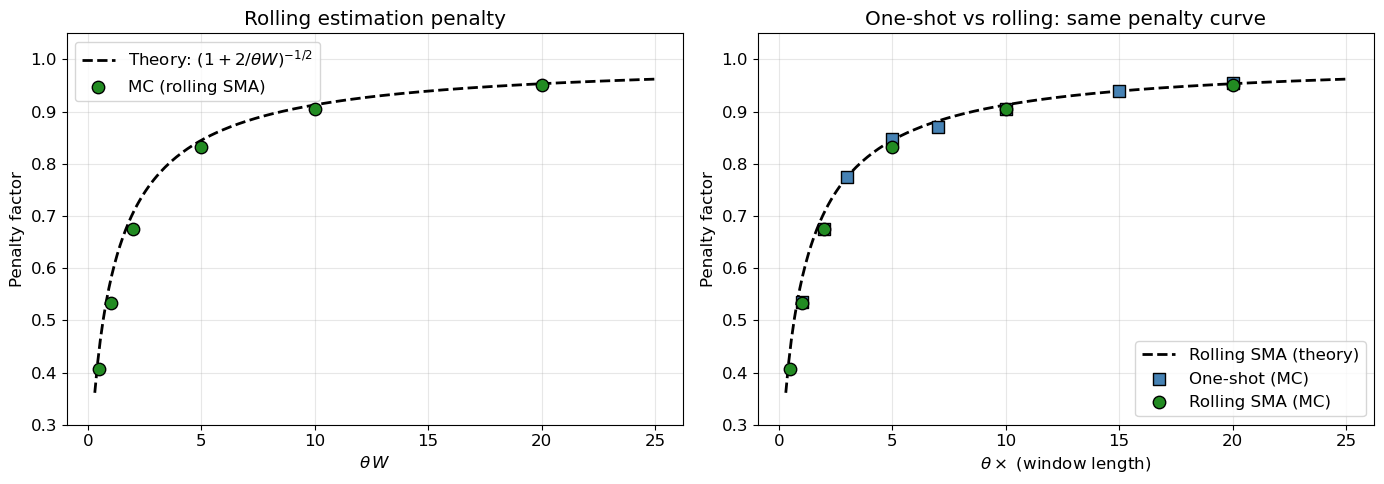

  W=  0.5yr  θW=  0.5  SR_mc=0.2871  penalty_mc=0.406  penalty_theory=0.447
  W=  1.0yr  θW=  1.0  SR_mc=0.3777  penalty_mc=0.534  penalty_theory=0.577
  W=  2.0yr  θW=  2.0  SR_mc=0.4769  penalty_mc=0.674  penalty_theory=0.707
  W=  5.0yr  θW=  5.0  SR_mc=0.5890  penalty_mc=0.833  penalty_theory=0.845
  W= 10.0yr  θW= 10.0  SR_mc=0.6405  penalty_mc=0.906  penalty_theory=0.913
  W= 20.0yr  θW= 20.0  SR_mc=0.6721  penalty_mc=0.950  penalty_theory=0.953


In [16]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-rolling-estimation
#| fig-cap: "Rolling SMA penalty vs window length. Left: MC penalty factor for rolling SMA against the theoretical curve $(1+2/\\theta W)^{-1/2}$. Right: one-shot and rolling penalties overlaid on the same curve, confirming they share identical functional form."
# --- Rolling estimation: SMA bias simulation ---
theta_true, sigma_true = 1.0, 1.0
dt = 1 / 252
T = 50                 # total simulation length
n_paths = 2000
W_values = [0.5, 1, 2, 5, 10, 20]

sr_rolling_mc = []

for W in W_values:
    W_steps = int(W / dt)
    X = simulate_ou(theta_true, sigma_true, T, dt, n_paths,
                    rng=np.random.default_rng(123))
    # Compute rolling SMA bias: M_t = (1/W) * integral_{t-W}^{t} X_s ds
    cumX = np.cumsum(X, axis=1) * dt
    M = np.zeros_like(X)
    for k in range(W_steps, X.shape[1]):
        M[:, k] = (cumX[:, k] - cumX[:, k - W_steps]) / W

    # Only measure SR after the window is fully populated
    burn = W_steps + int(5 / dt)
    if burn >= X.shape[1] - int(5 / dt):
        burn = W_steps
    X_eval = X[:, burn:]
    M_eval = M[:, burn:]
    T_eval = (X_eval.shape[1] - 1) * dt

    # SR = mean(annualised PnL) / sqrt(mean(annualised QV_Y))
    Y = pnl_paths(X_eval, M_eval, dt)
    mean_pnl = np.mean(Y[:, -1] / T_eval)
    dX_eval = np.diff(X_eval, axis=1)
    dY = -(X_eval[:, :-1] - M_eval[:, :-1]) * dX_eval
    qvY = np.sum(dY**2, axis=1)
    mean_qvY = np.mean(qvY / T_eval)
    sr_rolling_mc.append(mean_pnl / np.sqrt(mean_qvY))

sr_rolling_mc = np.array(sr_rolling_mc)

# --- Plot: rolling SR vs window ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: penalty factor vs theta*W
W_fine = np.linspace(0.3, 25, 200)
penalty_fine = 1 / np.sqrt(1 + 2 / (theta_true * W_fine))
axes[0].plot(theta_true * W_fine, penalty_fine, 'k--', lw=2,
             label=r'Theory: $(1 + 2/\theta W)^{-1/2}$')
penalty_rolling = sr_rolling_mc / np.sqrt(theta_true / 2)
axes[0].scatter(theta_true * np.array(W_values), penalty_rolling, s=80,
                c='forestgreen', zorder=5, edgecolors='black', label='MC (rolling SMA)')
axes[0].set_xlabel(r'$\theta \, W$')
axes[0].set_ylabel('Penalty factor')
axes[0].set_title('Rolling estimation penalty')
axes[0].legend()
axes[0].set_ylim(0.3, 1.05)

# Right: compare one-shot vs rolling
axes[1].plot(theta_true * W_fine, penalty_fine, 'k--', lw=2, label='Rolling SMA (theory)')
# Overlay one-shot results from previous cell
axes[1].scatter(theta_true * T_est_grid, sr_mc / np.sqrt(theta_true / 2),
                s=80, c='steelblue', zorder=5, edgecolors='black',
                marker='s', label='One-shot (MC)')
axes[1].scatter(theta_true * np.array(W_values), penalty_rolling, s=80,
                c='forestgreen', zorder=5, edgecolors='black',
                marker='o', label='Rolling SMA (MC)')
axes[1].set_xlabel(r'$\theta \times$ (window length)')
axes[1].set_ylabel('Penalty factor')
axes[1].set_title('One-shot vs rolling: same penalty curve')
axes[1].legend()
axes[1].set_ylim(0.3, 1.05)

fig.tight_layout()
plt.show()

for W, sr in zip(W_values, sr_rolling_mc):
    th_penalty = 1 / np.sqrt(1 + 2 / (theta_true * W))
    print(f"  W={W:>5.1f}yr  θW={theta_true*W:>5.1f}  SR_mc={sr:.4f}  "
          f"penalty_mc={sr/np.sqrt(theta_true/2):.3f}  penalty_theory={th_penalty:.3f}")

# Bias in $\hat\theta$

It is well known that the MLE overestimates $\theta$ in finite samples: the median $\hat\theta$ exceeds the true value, as shown in @fig-mle-bias. A natural question is whether this bias can degrade the realised Sharpe ratio in practice.

It turns out that it does not, at least not directly. The realised SR, defined as $Y_T / \sqrt{[Y]_T}$, depends only on the actual mispricing process and the trader's fair-value estimate. Using $\hat\theta$ instead of the true $\theta$ for position sizing simply scales all positions uniformly, and this common factor cancels in the ratio.

However, a trader who computes the predicted Sharpe ratio $\mathrm{SR}_\infty = \sqrt{\hat\theta/2}$ will arrive at a systematic overestimate, since $\hat\theta$ is upward-biased. The resulting overconfidence distorts capital allocation: more capital or higher leverage is deployed than the strategy's actual risk–reward profile warrants. Risk budgets calibrated to the inflated SR become too tight, raising the probability of premature stop-outs during normal drawdowns. In a multi-strategy portfolio, the allocation problem is compounded — the strategy with the shortest calibration window appears most attractive precisely because its $\hat\theta$ is the most inflated. @fig-overconfidence quantifies this gap between predicted and realised SR for calibration windows of 2–20 years.

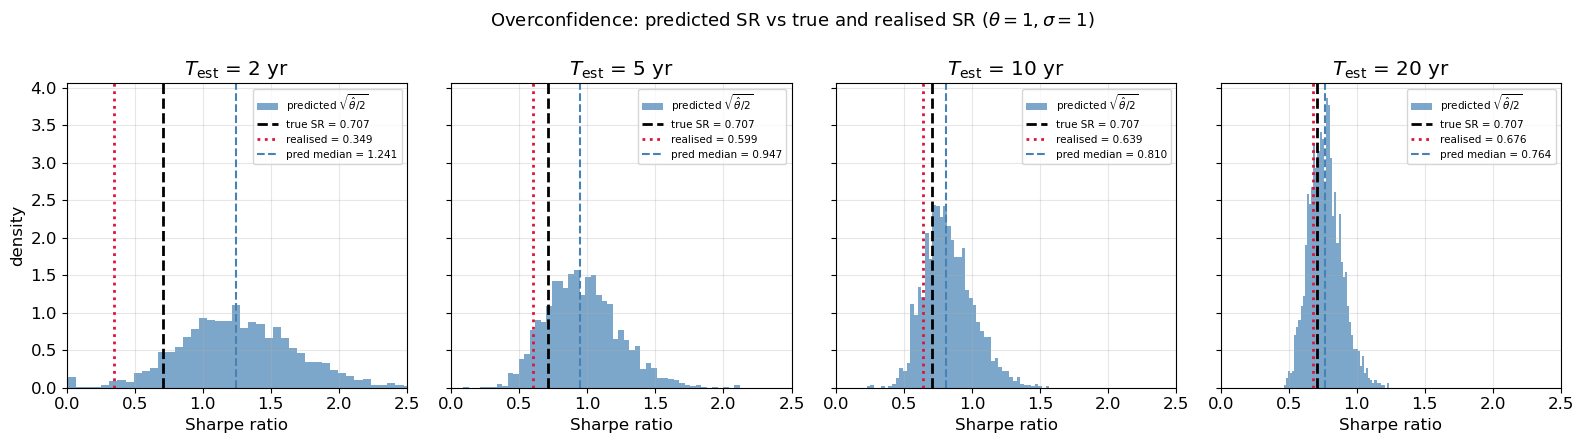

 T_est | median predicted |    true SR |  realised SR |  overconfidence
----------------------------------------------------------------------
     2 |           1.2413 |     0.7071 |       0.3486 |          0.8927
     5 |           0.9465 |     0.7071 |       0.5990 |          0.3475
    10 |           0.8098 |     0.7071 |       0.6393 |          0.1705
    20 |           0.7642 |     0.7071 |       0.6758 |          0.0884


In [17]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-overconfidence
#| fig-cap: "Distribution of predicted SR $\\sqrt{\\hat\\theta/2}$ vs true and realised SR for calibration lengths of 2, 5, 10, and 20 years. The median prediction systematically exceeds realised SR, with the gap narrowing as the calibration window lengthens."
# --- Overconfidence: predicted vs realised SR ---
theta_true, sigma_true = 1.0, 1.0
dt = 1 / 252
T_trade = 100
n_mc = 2000
T_est_values = [2, 5, 10, 20]

fig, axes = plt.subplots(1, len(T_est_values), figsize=(16, 4.5), sharey=True)

for j, T_est in enumerate(T_est_values):
    theta_hats = []
    pnl_ann_list = []
    qvY_ann_list = []
    for i in range(n_mc):
        seed = int(50000 * j + i)
        X_full = simulate_ou(theta_true, sigma_true, T_est + T_trade, dt, 1,
                             rng=np.random.default_rng(seed))
        n_est = int(T_est / dt)
        X_cal = X_full[0, :n_est + 1]
        X_trade = X_full[:, n_est:]

        th_hat, mu_hat, _ = mle_ou(X_cal, dt)
        theta_hats.append(th_hat)

        # Realised PnL and QV_Y for cross-path SR
        Y = pnl_paths(X_trade, mu_hat, dt)
        pnl_ann_list.append(Y[0, -1] / T_trade)
        dX_tr = np.diff(X_trade, axis=1)
        dY = -(X_trade[:, :-1] - mu_hat) * dX_tr
        qvY_ann_list.append(np.sum(dY**2, axis=1)[0] / T_trade)

    theta_hats = np.array(theta_hats)
    predicted_srs = np.sqrt(theta_hats / 2)
    realized_sr = np.mean(pnl_ann_list) / np.sqrt(np.mean(qvY_ann_list))
    theory_sr = np.sqrt(theta_true / 2) / np.sqrt(1 + 2 / (theta_true * T_est))

    ax = axes[j]
    ax.hist(predicted_srs, bins=50, density=True, alpha=0.7, color='steelblue',
            label=f'predicted $\\sqrt{{\\hat\\theta/2}}$')
    ax.axvline(np.sqrt(theta_true / 2), color='black', ls='--', lw=2,
               label=f'true SR = {np.sqrt(theta_true/2):.3f}')
    ax.axvline(realized_sr, color='crimson', ls=':', lw=2,
               label=f'realised = {realized_sr:.3f}')
    ax.axvline(np.median(predicted_srs), color='steelblue', ls='--', lw=1.5,
               label=f'pred median = {np.median(predicted_srs):.3f}')
    ax.set_title(f'$T_{{\\mathrm{{est}}}}$ = {T_est} yr')
    ax.set_xlabel(r'Sharpe ratio')
    if j == 0:
        ax.set_ylabel('density')
    ax.legend(fontsize=7.5, loc='upper right')
    ax.set_xlim(0, 2.5)

fig.suptitle(r'Overconfidence: predicted SR vs true and realised SR ($\theta=1, \sigma=1$)',
             fontsize=13)
fig.tight_layout()
plt.show()

# Summary table
print(f"{'T_est':>6} | {'median predicted':>16} | {'true SR':>10} | {'realised SR':>12} | {'overconfidence':>15}")
print("-" * 70)
for j, T_est in enumerate(T_est_values):
    theta_hats = []
    pnl_ann, qvY_ann = [], []
    for i in range(n_mc):
        seed = int(50000 * j + i)
        X_full = simulate_ou(theta_true, sigma_true, T_est + T_trade, dt, 1,
                             rng=np.random.default_rng(seed))
        n_est = int(T_est / dt)
        X_cal = X_full[0, :n_est + 1]
        X_trade = X_full[:, n_est:]
        th_hat, mu_hat, _ = mle_ou(X_cal, dt)
        theta_hats.append(th_hat)
        Y = pnl_paths(X_trade, mu_hat, dt)
        pnl_ann.append(Y[0, -1] / T_trade)
        dX_tr = np.diff(X_trade, axis=1)
        dY = -(X_trade[:, :-1] - mu_hat) * dX_tr
        qvY_ann.append(np.sum(dY**2, axis=1)[0] / T_trade)

    pred_median = np.median(np.sqrt(np.array(theta_hats) / 2))
    real_sr = np.mean(pnl_ann) / np.sqrt(np.mean(qvY_ann))
    true_sr = np.sqrt(theta_true / 2)
    print(f"{T_est:>6} | {pred_median:>16.4f} | {true_sr:>10.4f} | {real_sr:>12.4f} | {pred_median - real_sr:>15.4f}")

# Discussion

The central result of this post is a closed-form expression for the estimation penalty on Sharpe ratio. When a trader calibrates the OU process on a window of length $T_{\mathrm{est}}$ and then trades with the estimated fair value, the asymptotic Sharpe ratio is $\mathrm{SR}_\infty = \sqrt{\theta/2}\,(1 + 2/(\theta T_{\mathrm{est}}))^{-1/2}$, as confirmed by Monte Carlo in @fig-sr-estimation and tabulated in @tbl-estimation-penalty. The penalty depends entirely on $\theta T_{\mathrm{est}}$, the number of mean-reversion timescales observed during calibration. Slow mean reversion (small $\theta$) demands proportionally longer calibration to achieve the same penalty level.

A key structural distinction separates one-shot estimation from rolling re-estimation. The one-shot estimator $\hat\mu$ is fixed at the end of calibration and is independent of subsequent Brownian increments, so it enters as a Part 2 constant bias whose correlation with the trading-window process decays exponentially. For long trading horizons, the Part 3 covariance channel washes out entirely and only the variance penalty remains. The rolling estimator, by contrast, continuously updates $\hat\mu$ using a trailing window of length $W$, creating a permanent positive correlation between the bias and the mispricing. Although the resulting penalty $(1 + 2/(\theta W))^{-1/2}$ has the same functional form as the one-shot case, it persists at all trading horizons — a structural cost of continuous re-estimation (@fig-rolling-estimation, @tbl-oneshot-vs-rolling).